## Ejercicio 3: Inspección visual de un producto

### Ficha PEAS
* **P (Performance / Desempeño):** Garantizar la calidad del producto final y minimizar falsos descartes o reprocesos innecesarios[cite: 2].
* **E (Environment / Entorno):** Línea de producción industrial y sistema óptico de visión artificial[cite: 2].
* **A (Actuators / Actuadores):** Clasificar y derivar el producto: "aprobar", "revisión manual" o "rechazar"[cite: 2].
* **S (Sensors / Sensores):** Matriz NumPy de 5x5 píxeles (0 = píxel normal, 1 = píxel defectuoso)[cite: 2].

### Justificación de las reglas
Las reglas responden a estándares de control de calidad industrial. Si una pieza presenta 0 píxeles defectuosos, cumple el estándar perfecto y se aprueba de inmediato[cite: 2]. Si presenta entre 1 y 3 píxeles defectuosos, se envía a "revisión manual" debido a que podría tratarse de una falla menor corregible o un error de lectura por suciedad en la cámara[cite: 2]. Si detecta más de 3 píxeles defectuosos, el daño estructural es severo e irrecuperable, procediendo al rechazo definitivo[cite: 2].

### Código

In [4]:
import numpy as np

def agente_inspeccion(imagen):
    # Percepción (S): matriz 5x5 de NumPy (0 = normal, 1 = defectuoso).
    # Retorna una tupla (acción, motivo).
    if not isinstance(imagen, np.ndarray) or imagen.shape != (5, 5):
        return "dato inválido", "la imagen debe ser una matriz NumPy de 5x5"
    if not np.all(np.isin(imagen, [0, 1])):
        return "dato inválido", "la matriz solo puede contener valores 0 y 1"

    defectos = int(np.count_nonzero(imagen == 1))

    if defectos == 0:
        return "aprobar", "no se detectaron píxeles defectuosos"
    if defectos <= 3:
        return "revisión manual", f"se detectaron {defectos} píxeles defectuosos"
    return "rechazar", f"se detectaron {defectos} píxeles defectuosos, más del límite permitido"

### Simulación y pruebas

In [5]:
import matplotlib.pyplot as plt

imagenes_prueba = {
    "0 defectos": np.zeros((5, 5), dtype=int),
    "1 defecto": np.array([
        [0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
    ]),
    "3 defectos (borde revisión)": np.array([
        [1, 0, 0, 0, 0],
        [0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0],
    ]),
    "4 defectos (borde rechazo)": np.array([
        [1, 0, 0, 0, 1],
        [0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0],
    ]),
}

for nombre, imagen in imagenes_prueba.items():
    accion, motivo = agente_inspeccion(imagen)
    print(f"{nombre:<28} -> {accion}: {motivo}")



0 defectos                   -> aprobar: no se detectaron píxeles defectuosos
1 defecto                    -> revisión manual: se detectaron 1 píxeles defectuosos
3 defectos (borde revisión)  -> revisión manual: se detectaron 3 píxeles defectuosos
4 defectos (borde rechazo)   -> rechazar: se detectaron 4 píxeles defectuosos, más del límite permitido


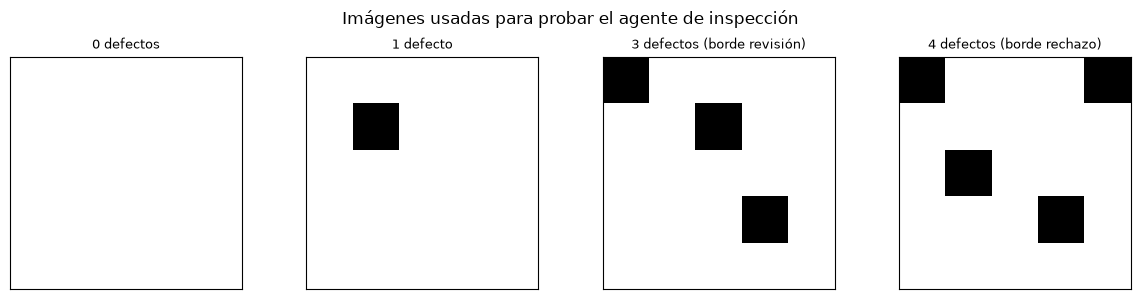

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, (nombre, imagen) in zip(axes, imagenes_prueba.items()):
    ax.imshow(imagen, cmap="gray_r", vmin=0, vmax=1)
    ax.set_title(nombre, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle("Imágenes usadas para probar el agente de inspección")
plt.tight_layout()
plt.show()